<a href="https://colab.research.google.com/github/Sathya-242006/CancerDriverGenePrediction/blob/main/cancerdrivergene.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load directly from your Drive folder
df = pd.read_csv('/content/final_cancer_driver_dataset.csv')

print("✅ Dataset loaded!")
print("Shape:", df.shape)
print(df.head())

✅ Dataset loaded!
Shape: (1133, 6)
  gene_symbol  mutation_count  sample_count  cohort_count  impact_score  label
0       GRIK2             3.0          34.0             1  4.794341e-09      0
1      NPEPPS             7.0         293.0             2  1.228007e-05      0
2      PIK3CA          2794.0        2473.0           109  1.294649e-01      1
3       RASA2             5.0           4.0             1  3.305785e-02      1
4         ERF             8.0         444.0             1  5.129514e-06      0


In [ ]:
# Install xgboost (already available in Colab but good practice)
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             roc_curve)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
print("Shape:", df.shape)
print()
print("Column names:", df.columns.tolist())
print()
print("Data types:\n", df.dtypes)
print()
print("Null values:\n", df.isnull().sum())
print()
print("Label distribution:\n", df['label'].value_counts())

Shape: (1133, 6)

Column names: ['gene_symbol', 'mutation_count', 'sample_count', 'cohort_count', 'impact_score', 'label']

Data types:
 gene_symbol        object
mutation_count    float64
sample_count      float64
cohort_count        int64
impact_score      float64
label               int64
dtype: object

Null values:
 gene_symbol       0
mutation_count    0
sample_count      0
cohort_count      0
impact_score      0
label             0
dtype: int64

Label distribution:
 label
1    633
0    500
Name: count, dtype: int64


In [ ]:
df['mutation_count'] = df['mutation_count'].astype(int)
df['sample_count']   = df['sample_count'].astype(int)

print("✅ Data types fixed!")
print(df.dtypes)

✅ Data types fixed!
gene_symbol        object
mutation_count      int64
sample_count        int64
cohort_count        int64
impact_score      float64
label               int64
dtype: object


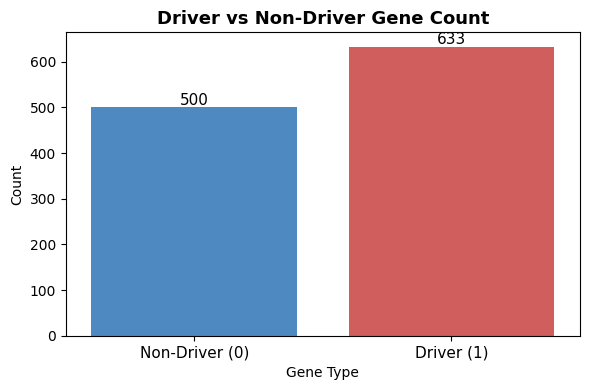

✅ Plot 1 saved!


In [ ]:
import os

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df,
                   palette={'0': '#3B8BD4', '1': '#E24B4A'})
plt.xticks([0, 1], ['Non-Driver (0)', 'Driver (1)'], fontsize=11)
plt.title('Driver vs Non-Driver Gene Count', fontsize=13, fontweight='bold')
plt.xlabel('Gene Type')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                ha='center', fontsize=11)
plt.tight_layout()

# Define the directory path
plot_dir = '/content/drive/MyDrive/Cancer_driver_project/'

# Create the directory if it doesn't exist
os.makedirs(plot_dir, exist_ok=True)

# Save the plot
plt.savefig(plot_dir + 'plot1_label_distribution.png', dpi=150)
plt.show()
print("✅ Plot 1 saved!")

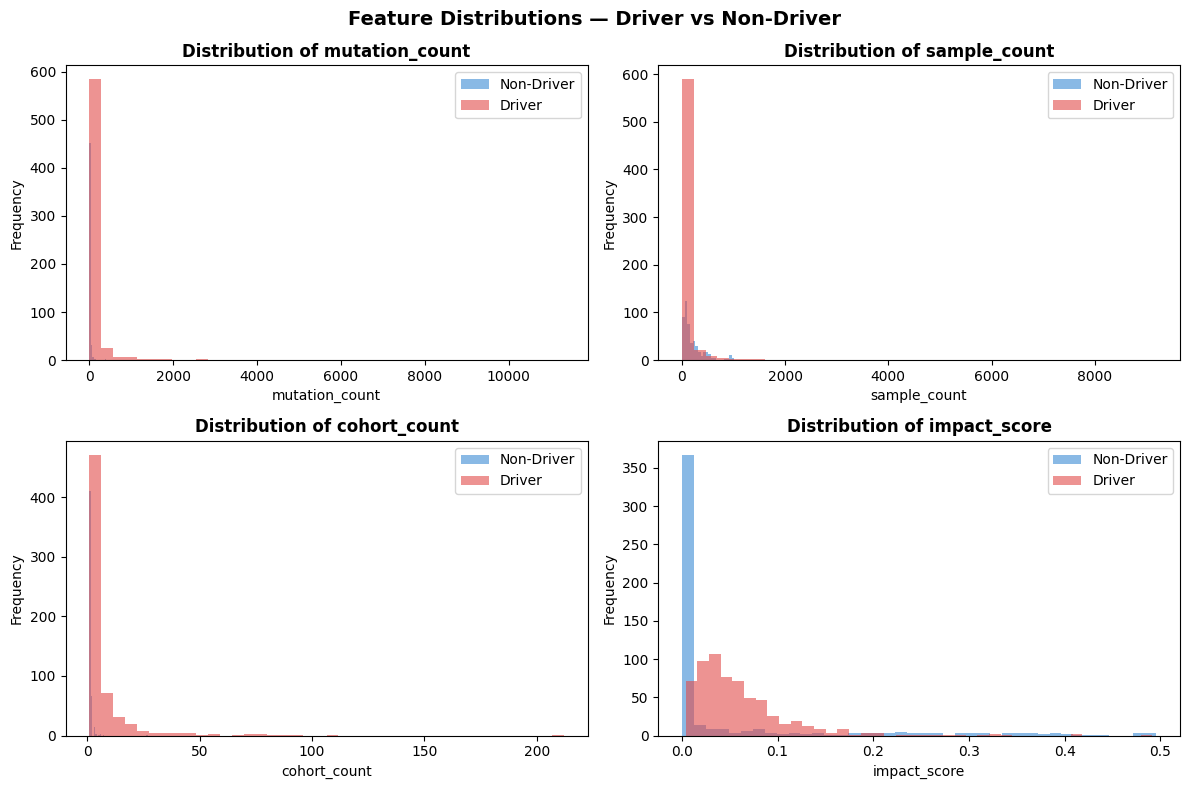

✅ Plot 2 saved!


In [ ]:
features = ['mutation_count', 'sample_count', 'cohort_count', 'impact_score']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = {0: '#3B8BD4', 1: '#E24B4A'}
labels_map = {0: 'Non-Driver', 1: 'Driver'}

for i, feat in enumerate(features):
    ax = axes[i//2][i%2]
    for label_val in [0, 1]:
        subset = df[df['label'] == label_val][feat]
        ax.hist(subset, bins=40, alpha=0.6,
                color=colors[label_val],
                label=labels_map[label_val])
    ax.set_title(f'Distribution of {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions — Driver vs Non-Driver',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cancer_driver_project/plot2_feature_distributions.png', dpi=150)
plt.show()
print("✅ Plot 2 saved!")

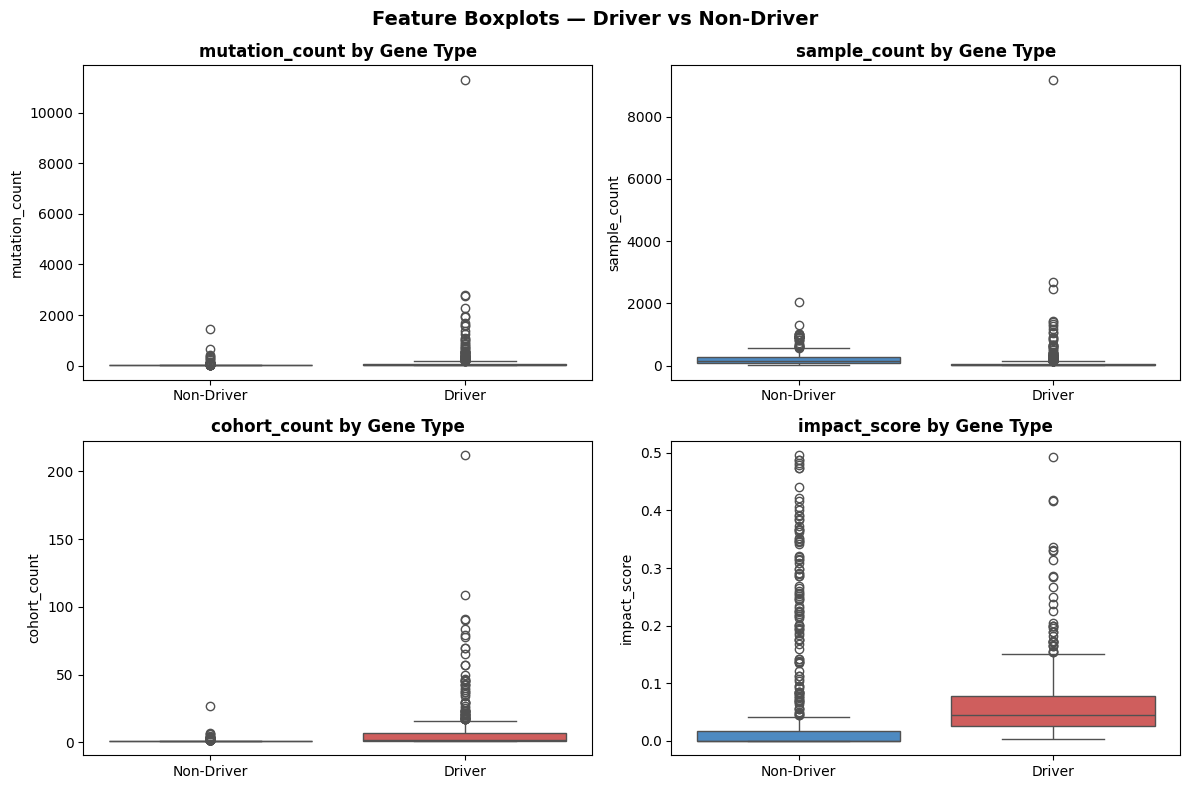

✅ Plot 3 saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['mutation_count', 'sample_count', 'cohort_count', 'impact_score']

for i, feat in enumerate(features):
    ax = axes[i//2][i%2]
    sns.boxplot(x='label', y=feat, data=df, ax=ax,
                palette={'0': '#3B8BD4', '1': '#E24B4A'})
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Driver', 'Driver'])
    ax.set_title(f'{feat} by Gene Type', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Feature Boxplots — Driver vs Non-Driver',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cancer_driver_project/plot3_boxplots.png', dpi=150)
plt.show()
print("✅ Plot 3 saved!")

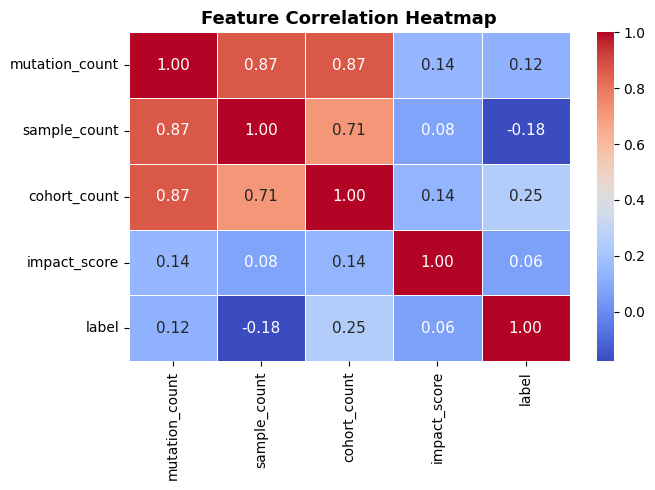

✅ Plot 4 saved!


In [ ]:
features = ['mutation_count', 'sample_count', 'cohort_count', 'impact_score']

plt.figure(figsize=(7, 5))
corr = df[features + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cancer_driver_project/plot4_correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Plot 4 saved!")

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and label
X = df[['mutation_count', 'sample_count', 'cohort_count', 'impact_score']]
y = df['label']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Data split done!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n",  y_test.value_counts())

✅ Data split done!
X_train shape: (906, 4)
X_test shape:  (227, 4)
y_train distribution:
 label
1    506
0    400
Name: count, dtype: int64
y_test distribution:
 label
1    127
0    100
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done!")
print("X_train_scaled mean (should be ~0):", X_train_scaled.mean().round(4))
print("X_train_scaled std  (should be ~1):", X_train_scaled.std().round(4))

✅ Scaling done!
X_train_scaled mean (should be ~0): 0.0
X_train_scaled std  (should be ~1): 1.0


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression trained!")
print("Accuracy:", round(accuracy_score(y_test, lr_preds), 4))

✅ Logistic Regression trained!
Accuracy: 0.9471


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Random Forest trained!")
print("Accuracy:", round(accuracy_score(y_test, rf_preds), 4))

✅ Random Forest trained!
Accuracy: 1.0


In [ ]:
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(scale_pos_weight=scale, random_state=42,
                           eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("✅ XGBoost trained!")
print("Accuracy:", round(accuracy_score(y_test, xgb_preds), 4))

✅ XGBoost trained!
Accuracy: 0.9912


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

models = {
    'Logistic Regression': (lr_preds, lr_probs),
    'Random Forest':       (rf_preds, rf_probs),
    'XGBoost':             (xgb_preds, xgb_probs)
}

results = []
for name, (preds, probs) in models.items():
    acc  = round(accuracy_score(y_test, preds)  * 100, 2)
    f1   = round(f1_score(y_test, preds)        * 100, 2)
    auc  = round(roc_auc_score(y_test, probs)   * 100, 2)
    results.append({'Model': name, 'Accuracy %': acc, 'F1 Score %': f1, 'AUC %': auc})

results_df = pd.DataFrame(results)
print("=" * 55)
print("        MODEL COMPARISON RESULTS")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

        MODEL COMPARISON RESULTS
              Model  Accuracy %  F1 Score %  AUC %
Logistic Regression       94.71       95.45  98.06
      Random Forest      100.00      100.00 100.00
            XGBoost       99.12       99.22 100.00


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 50)
print("  5-FOLD CROSS VALIDATION RESULTS")
print("=" * 50)

for name, model in [
    ('Logistic Regression', LogisticRegression(class_weight='balanced',
                            random_state=42, max_iter=1000)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100,
                            class_weight='balanced', random_state=42)),
    ('XGBoost',             XGBClassifier(scale_pos_weight=scale,
                            random_state=42, eval_metric='logloss',
                            verbosity=0))
]:
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=kfold, scoring='accuracy')
    print(f"{name}:")
    print(f"  Scores per fold: {[round(s*100,2) for s in scores]}")
    print(f"  Mean accuracy : {round(scores.mean()*100, 2)}%")
    print(f"  Std deviation : {round(scores.std()*100, 2)}%")
    print()

  5-FOLD CROSS VALIDATION RESULTS
Logistic Regression:
  Scores per fold: [np.float64(95.05), np.float64(95.03), np.float64(93.37), np.float64(93.37), np.float64(96.13)]
  Mean accuracy : 94.59%
  Std deviation : 1.07%

Random Forest:
  Scores per fold: [np.float64(100.0), np.float64(98.9), np.float64(100.0), np.float64(98.9), np.float64(100.0)]
  Mean accuracy : 99.56%
  Std deviation : 0.54%

XGBoost:
  Scores per fold: [np.float64(99.45), np.float64(99.45), np.float64(97.24), np.float64(98.9), np.float64(99.45)]
  Mean accuracy : 98.9%
  Std deviation : 0.86%



In [ ]:
results = []
for name, (preds, probs) in {
    'Logistic Regression': (lr_preds, lr_probs),
    'Random Forest':       (rf_preds, rf_probs),
    'XGBoost':             (xgb_preds, xgb_probs)
}.items():
    acc = round(accuracy_score(y_test, preds)  * 100, 2)
    f1  = round(f1_score(y_test, preds)        * 100, 2)
    auc = round(roc_auc_score(y_test, probs)   * 100, 2)
    results.append({'Model': name, 'Accuracy %': acc,
                    'F1 Score %': f1, 'AUC %': auc})

results_df = pd.DataFrame(results)
print("=" * 55)
print("       MODEL COMPARISON RESULTS")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)
print("\n✅ Best Model: Random Forest")

       MODEL COMPARISON RESULTS
              Model  Accuracy %  F1 Score %  AUC %
Logistic Regression       94.71       95.45  98.06
      Random Forest      100.00      100.00 100.00
            XGBoost       99.12       99.22 100.00

✅ Best Model: Random Forest


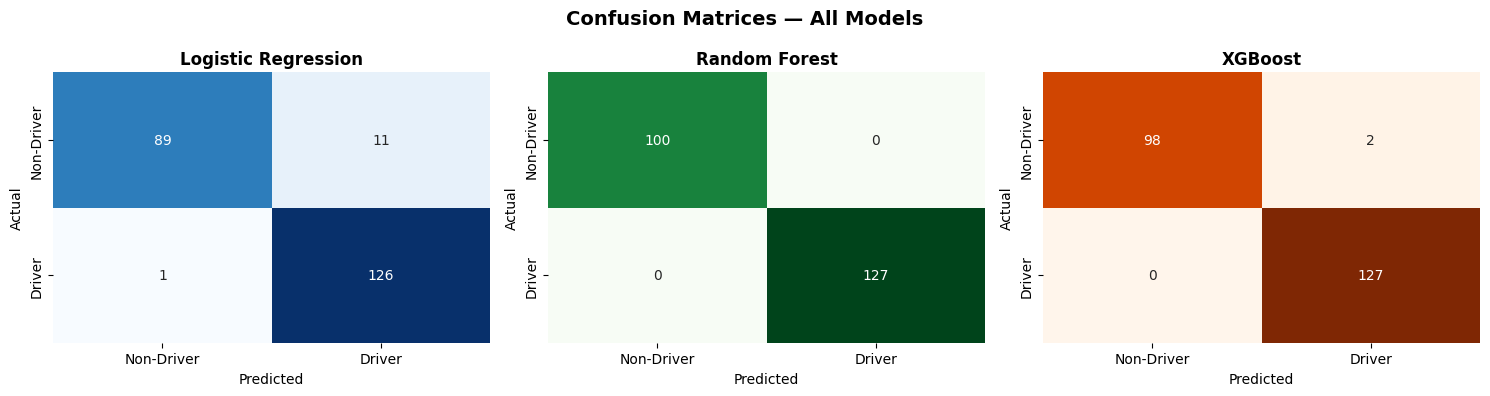

✅ Plot 5 saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
model_preds = [lr_preds, rf_preds, xgb_preds]
cmaps       = ['Blues', 'Greens', 'Oranges']

for i, (name, preds, cmap) in enumerate(
        zip(model_names, model_preds, cmaps)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                ax=axes[i], cbar=False,
                xticklabels=['Non-Driver', 'Driver'],
                yticklabels=['Non-Driver', 'Driver'])
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cancer_driver_project/plot5_confusion_matrices.png',
            dpi=150)
plt.show()
print("✅ Plot 5 saved!")

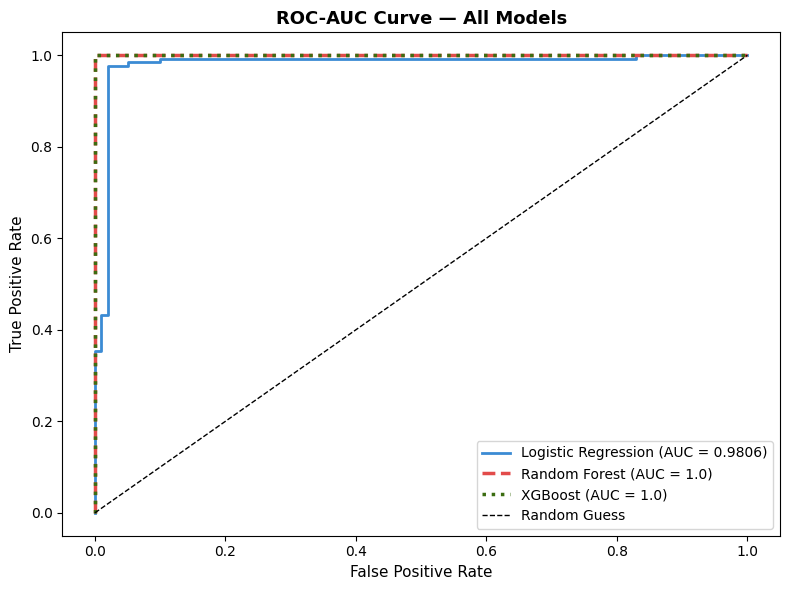

✅ Plot 6 saved!


In [ ]:
plt.figure(figsize=(8, 6))

models_roc = [
    ('Logistic Regression', lr_probs,  '#3B8BD4', '-',  2),
    ('Random Forest',       rf_probs,  '#E24B4A', '--', 2.5),
    ('XGBoost',             xgb_probs, '#3B6D11', ':',  2.5),
]

for name, probs, color, linestyle, lw in models_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = round(roc_auc_score(y_test, probs), 4)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc})',
             color=color, linewidth=lw, linestyle=linestyle)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-AUC Curve — All Models',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cancer_driver_project/plot6_roc_auc.png',
            dpi=150)
plt.show()
print("✅ Plot 6 saved!")

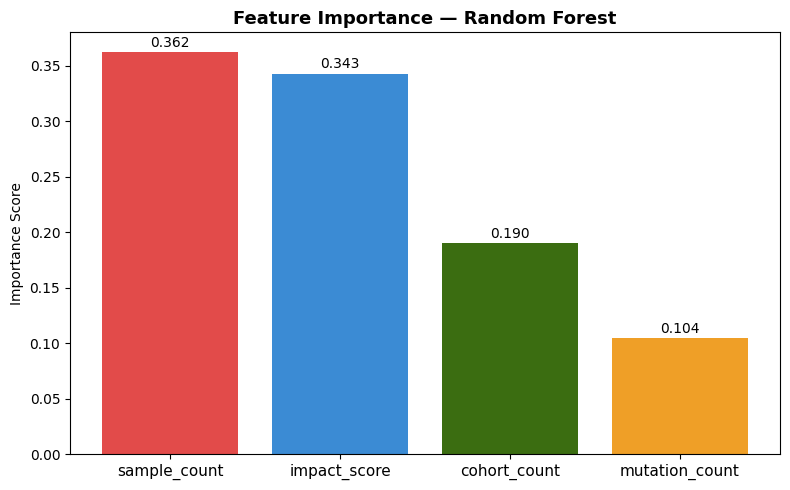

✅ Plot 7 saved!

Feature Rankings:
  sample_count: 0.3622
  impact_score: 0.3431
  cohort_count: 0.1902
  mutation_count: 0.1045


In [ ]:
features = ['mutation_count', 'sample_count',
            'cohort_count', 'impact_score']

importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
colors = ['#E24B4A', '#3B8BD4', '#3B6D11', '#EF9F27']
bars = plt.bar(range(len(features)),
               importances[indices],
               color=[colors[i] for i in range(len(features))])

plt.xticks(range(len(features)),
           [features[i] for i in indices], fontsize=11)
plt.title('Feature Importance — Random Forest',
          fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')

for bar, val in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Cancer_driver_project/plot7_feature_importance.png',
            dpi=150)
plt.show()

print("✅ Plot 7 saved!")
print("\nFeature Rankings:")
for i in indices:
    print(f"  {features[i]}: {importances[i]:.4f}")

In [ ]:
import joblib

# Save model and scaler
joblib.dump(rf_model, '/content/drive/MyDrive/Cancer_driver_project/rf_model.pkl')
joblib.dump(scaler,   '/content/drive/MyDrive/Cancer_driver_project/scaler.pkl')

print("✅ Model saved to Google Drive!")
print("✅ Scaler saved to Google Drive!")

✅ Model saved to Google Drive!
✅ Scaler saved to Google Drive!


## 📊 Real Gene Examples for Testing UI

### 🔴 Driver Genes
| Gene | Mutation | Sample | Cohort | Impact |
|---|---|---|---|---|
| PIK3CA | 2794 | 2473 | 109 | 0.129 |
| BCL7A | 51 | 31 | 4 | 0.041 |
| CHD2 | 53 | 43 | 7 | 0.056 |

### 🟢 Non-Driver Genes
| Gene | Mutation | Sample | Cohort | Impact |
|---|---|---|---|---|
| GRIK2 | 3 | 34 | 1 | 0.0000000048 |
| NPEPPS | 7 | 293 | 2 | 0.0000123 |
| ERF | 8 | 444 | 1 | 0.0000051 |

### 📈 Average Values
| Type | Mutation | Sample | Cohort | Impact |
|---|---|---|---|---|
| Driver avg | 120 | 92 | 7 | 0.061 |
| Non-Driver avg | 22 | 220 | 1 | 0.050 |

In [ ]:
import gradio as gr
import joblib
import numpy as np
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

rf_model = joblib.load('/content/drive/MyDrive/Cancer_driver_project/rf_model.pkl')
scaler   = joblib.load('/content/drive/MyDrive/Cancer_driver_project/scaler.pkl')

def predict_gene(mutation_count, sample_count,
                 cohort_count, impact_score):
    features = np.array([[mutation_count, sample_count,
                          cohort_count, impact_score]])
    features_scaled = scaler.transform(features)
    prediction  = rf_model.predict(features_scaled)[0]
    probability = rf_model.predict_proba(features_scaled)[0]
    confidence  = round(max(probability) * 100, 2)

    if prediction == 1:
        result = f"🔴 DRIVER GENE\nConfidence: {confidence}%"
        detail = ("This gene shows strong mutation patterns "
                  "consistent with cancer driver genes. "
                  "It may actively promote cancer growth.")
    else:
        result = f"🟢 NON-DRIVER GENE\nConfidence: {confidence}%"
        detail = ("This gene shows mutation patterns "
                  "consistent with passenger mutations. "
                  "It is unlikely to actively drive cancer.")

    return result, detail

with gr.Blocks(title="Cancer Driver Gene Predictor") as app:

    gr.Markdown("""
    # 🧬 Cancer Driver Gene Predictor
    ### Predict whether a gene is a Cancer Driver or Non-Driver
    """)

    with gr.Row():
        with gr.Column():
            mutation_count = gr.Number(
                label="Mutation Count",
                info="Total number of mutations in this gene",
                value=10)
            sample_count = gr.Number(
                label="Sample Count",
                info="Number of patient samples carrying this mutation",
                value=50)
            cohort_count = gr.Number(
                label="Cohort Count",
                info="Number of cancer cohorts where gene is mutated",
                value=3)
            impact_score = gr.Number(
                label="Impact Score",
                info="Statistical significance of mutation (0 to 1)",
                value=0.05)
            predict_btn = gr.Button("🔍 Predict", variant="primary")

        with gr.Column():
            result_out = gr.Textbox(
                label="Prediction Result", lines=2)
            detail_out = gr.Textbox(
                label="Biological Interpretation", lines=3)

    predict_btn.click(
        fn=predict_gene,
        inputs=[mutation_count, sample_count,
                cohort_count, impact_score],
        outputs=[result_out, detail_out]
    )

    gr.Markdown("""
    ---
    ### 📊 Real gene examples to test:
    | Gene | Type | Mutation | Sample | Cohort | Impact |
    |---|---|---|---|---|---|
    | PIK3CA |  Driver | 2794 | 2473 | 109 | 0.129 |
    | BCL7A |  Driver | 51 | 31 | 4 | 0.041 |
    | GRIK2 |  Non-Driver | 3 | 34 | 1 | 0.000000004 |
    | NPEPPS |  Non-Driver | 7 | 293 | 2 | 0.0000123 |
    """)

app.launch(share=True)

Mounted at /content/drive
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://317a79b33c0a85e7b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
